In [ ]:
!unzip "train.zip"
!unzip "test.zip"

Archive:  train.zip
   creating: train/
  inflating: __MACOSX/._train        
   creating: train/Ilex_Cornuta/
  inflating: __MACOSX/train/._Ilex_Cornuta  
   creating: train/Quercus_Castaneifolia/
  inflating: __MACOSX/train/._Quercus_Castaneifolia  
   creating: train/Quercus_Pyrenaica/
  inflating: __MACOSX/train/._Quercus_Pyrenaica  
   creating: train/Quercus_Ellipsoidalis/
  inflating: __MACOSX/train/._Quercus_Ellipsoidalis  
   creating: train/Viburnum_Tinus/
  inflating: __MACOSX/train/._Viburnum_Tinus  
   creating: train/Quercus_Trojana/
  inflating: __MACOSX/train/._Quercus_Trojana  
   creating: train/Populus_Adenopoda/
  inflating: __MACOSX/train/._Populus_Adenopoda  
   creating: train/Quercus_Vulcanica/
  inflating: __MACOSX/train/._Quercus_Vulcanica  
   creating: train/Quercus_Afares/
  inflating: __MACOSX/train/._Quercus_Afares  
   creating: train/Viburnum_x_Rhytidophylloides/
  inflating: __MACOSX/train/._Viburnum_x_Rhytidophylloides  
   creating: train/Cornus_Macr

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor

# MLP verison

In [ ]:
# Read the data
data = pd.read_csv("train.csv")
# Use the "id" column as the index
data.set_index("id", drop = True, inplace = True)

# String of "id" numbers for the test set
test_idx = "22   45   56   58   61   67   73   75   76   78   81   87   88  101  108  115 118  124  133  143  145  146  148  152  165  179  189  202  211  212  214  235 239  245  246  247  249  253  263  265  270  278  294  302  306  315  322  325 330  340  342  345  349  354  357  367  369  376  383  386  388  392  394  409 410  411  415  420  423  427  431  433  435  443  444  446  454  459  460  466 470  475  478  481  491  493  501  510  516  519  521  532  535  538  545  552 553  569  570  571  572  581  589  601  641  647  669  671  672  680  682  689 698  700  710  711  712  716  724  733  737  741  745  756  757  758  762  763 766  767  768  771  779  784  789  796  797  801  802  803  805  807  809  811 813  828  837  838  849  855  858  862  863  866  871  874  879  881  892  900 904  911  915  916  923  931  932  939  942  951  952  955  959  961  963  971 976  983  994 1001 1004 1014 1017 1019 1024 1025 1031 1039 1041 1051 1056 1061 1066 1073 1087 1101 1112 1113 1117 1118 1120 1125 1128 1130 1142 1148 1159 1160 1165 1172 1180 1194 1202 1205 1208 1210 1213 1218 1220 1228 1229 1238 1242 1249 1253 1255 1263 1265 1276 1281 1286 1309 1310 1317 1320 1327 1329 1330 1342 1344 1346 1348 1350 1358 1360 1366 1367 1372 1377 1378 1379 1388 1390 1391 1393 1394 1395 1402 1405 1411 1417 1420 1424 1435 1442 1443 1467 1474 1475 1479 1483 1494 1496 1499 1500 1501 1506 1507 1509 1511 1518 1523 1536 1539 1541 1545 1548 1551 1552 1554 1557 1561 1562 1569 1575 1581 1584"
# Split the string by whitespace
test_idx = test_idx.split()
# Convert the list to type integer
test_idx = list(map(int, test_idx))
# Get the training index
train_idx = list(set(data.index) - set(test_idx))

# Use the training index to separate the training data
train = data.loc[train_idx, :]
# Reset the index
train.reset_index(drop = True, inplace = True)
# Use the test index to separate the test data
test = data.loc[test_idx, :]
# Reset the index
test.reset_index(drop = True, inplace = True)

In [ ]:
print(data)

                    species   margin1   margin2   margin3   margin4   margin5  \
id                                                                              
1               Acer_Opalus  0.007812  0.023438  0.023438  0.003906  0.011719   
2     Pterocarya_Stenoptera  0.005859  0.000000  0.031250  0.015625  0.025391   
3      Quercus_Hartwissiana  0.005859  0.009766  0.019531  0.007812  0.003906   
5           Tilia_Tomentosa  0.000000  0.003906  0.023438  0.005859  0.021484   
6        Quercus_Variabilis  0.005859  0.003906  0.048828  0.009766  0.013672   
...                     ...       ...       ...       ...       ...       ...   
1575   Magnolia_Salicifolia  0.060547  0.119140  0.007812  0.003906  0.000000   
1578            Acer_Pictum  0.001953  0.003906  0.021484  0.107420  0.001953   
1581     Alnus_Maximowiczii  0.001953  0.003906  0.000000  0.021484  0.078125   
1582          Quercus_Rubra  0.000000  0.000000  0.046875  0.056641  0.009766   
1584         Quercus_Afares 

In [ ]:
# Separate features and targets
X = data.drop(columns=['id','species'])
y = data[['species']]

num_cols_X = X.shape[1]
num_cols_y = y.shape[1]

print("Number of columns in X:", num_cols_X)
print("Number of columns in y:", num_cols_y)

KeyError: "['id'] not found in axis"

In [ ]:
# Get all unique species in y and count them
unique_species = y['species'].unique()
num_unique_species = len(unique_species)

print("Number of unique species in y:", num_unique_species)

Number of unique species in y: 99


In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
y_test.nunique()

species    85
dtype: int64

In [ ]:
# Convert species labels to numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:134: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [ ]:
y_train_encoded

In [ ]:
# Build and compile the model
# Assuming num_unique_species is the number of unique species
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_unique_species, activation='softmax')  # Using softmax for multi-class classification
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_encoded, epochs=250, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f'Test loss: {loss:.3f}')
print(f'Test accuracy: {accuracy:.3f}')

Epoch 1/300
20/20 [==============================] - 2s 26ms/step - loss: 4.7342 - accuracy: 0.0111 - val_loss: 4.7365 - val_accuracy: 0.0189
Epoch 2/300
20/20 [==============================] - 0s 13ms/step - loss: 4.6935 - accuracy: 0.0190 - val_loss: 4.7137 - val_accuracy: 0.0189
Epoch 3/300
20/20 [==============================] - 0s 14ms/step - loss: 4.6662 - accuracy: 0.0111 - val_loss: 4.6942 - val_accuracy: 0.0189
Epoch 4/300
20/20 [==============================] - 0s 12ms/step - loss: 4.6417 - accuracy: 0.0205 - val_loss: 4.6766 - val_accuracy: 0.0189
Epoch 5/300
20/20 [==============================] - 0s 12ms/step - loss: 4.6022 - accuracy: 0.0142 - val_loss: 4.6573 - val_accuracy: 0.0314
Epoch 6/300
20/20 [==============================] - 0s 15ms/step - loss: 4.5874 - accuracy: 0.0190 - val_loss: 4.6366 - val_accuracy: 0.0440
Epoch 7/300
20/20 [==============================] - 0s 13ms/step - loss: 4.5648 - accuracy: 0.0205 - val_loss: 4.6138 - val_accuracy: 0.0314
Epoch 

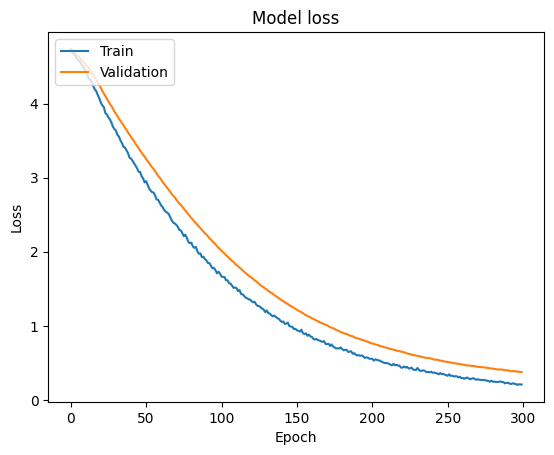

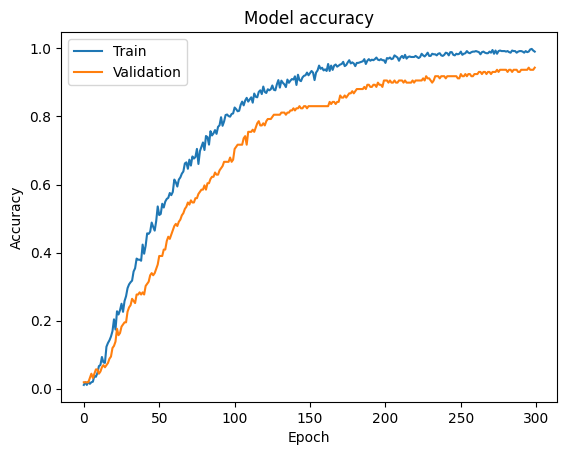

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

7/7 [==============================] - 0s 5ms/step


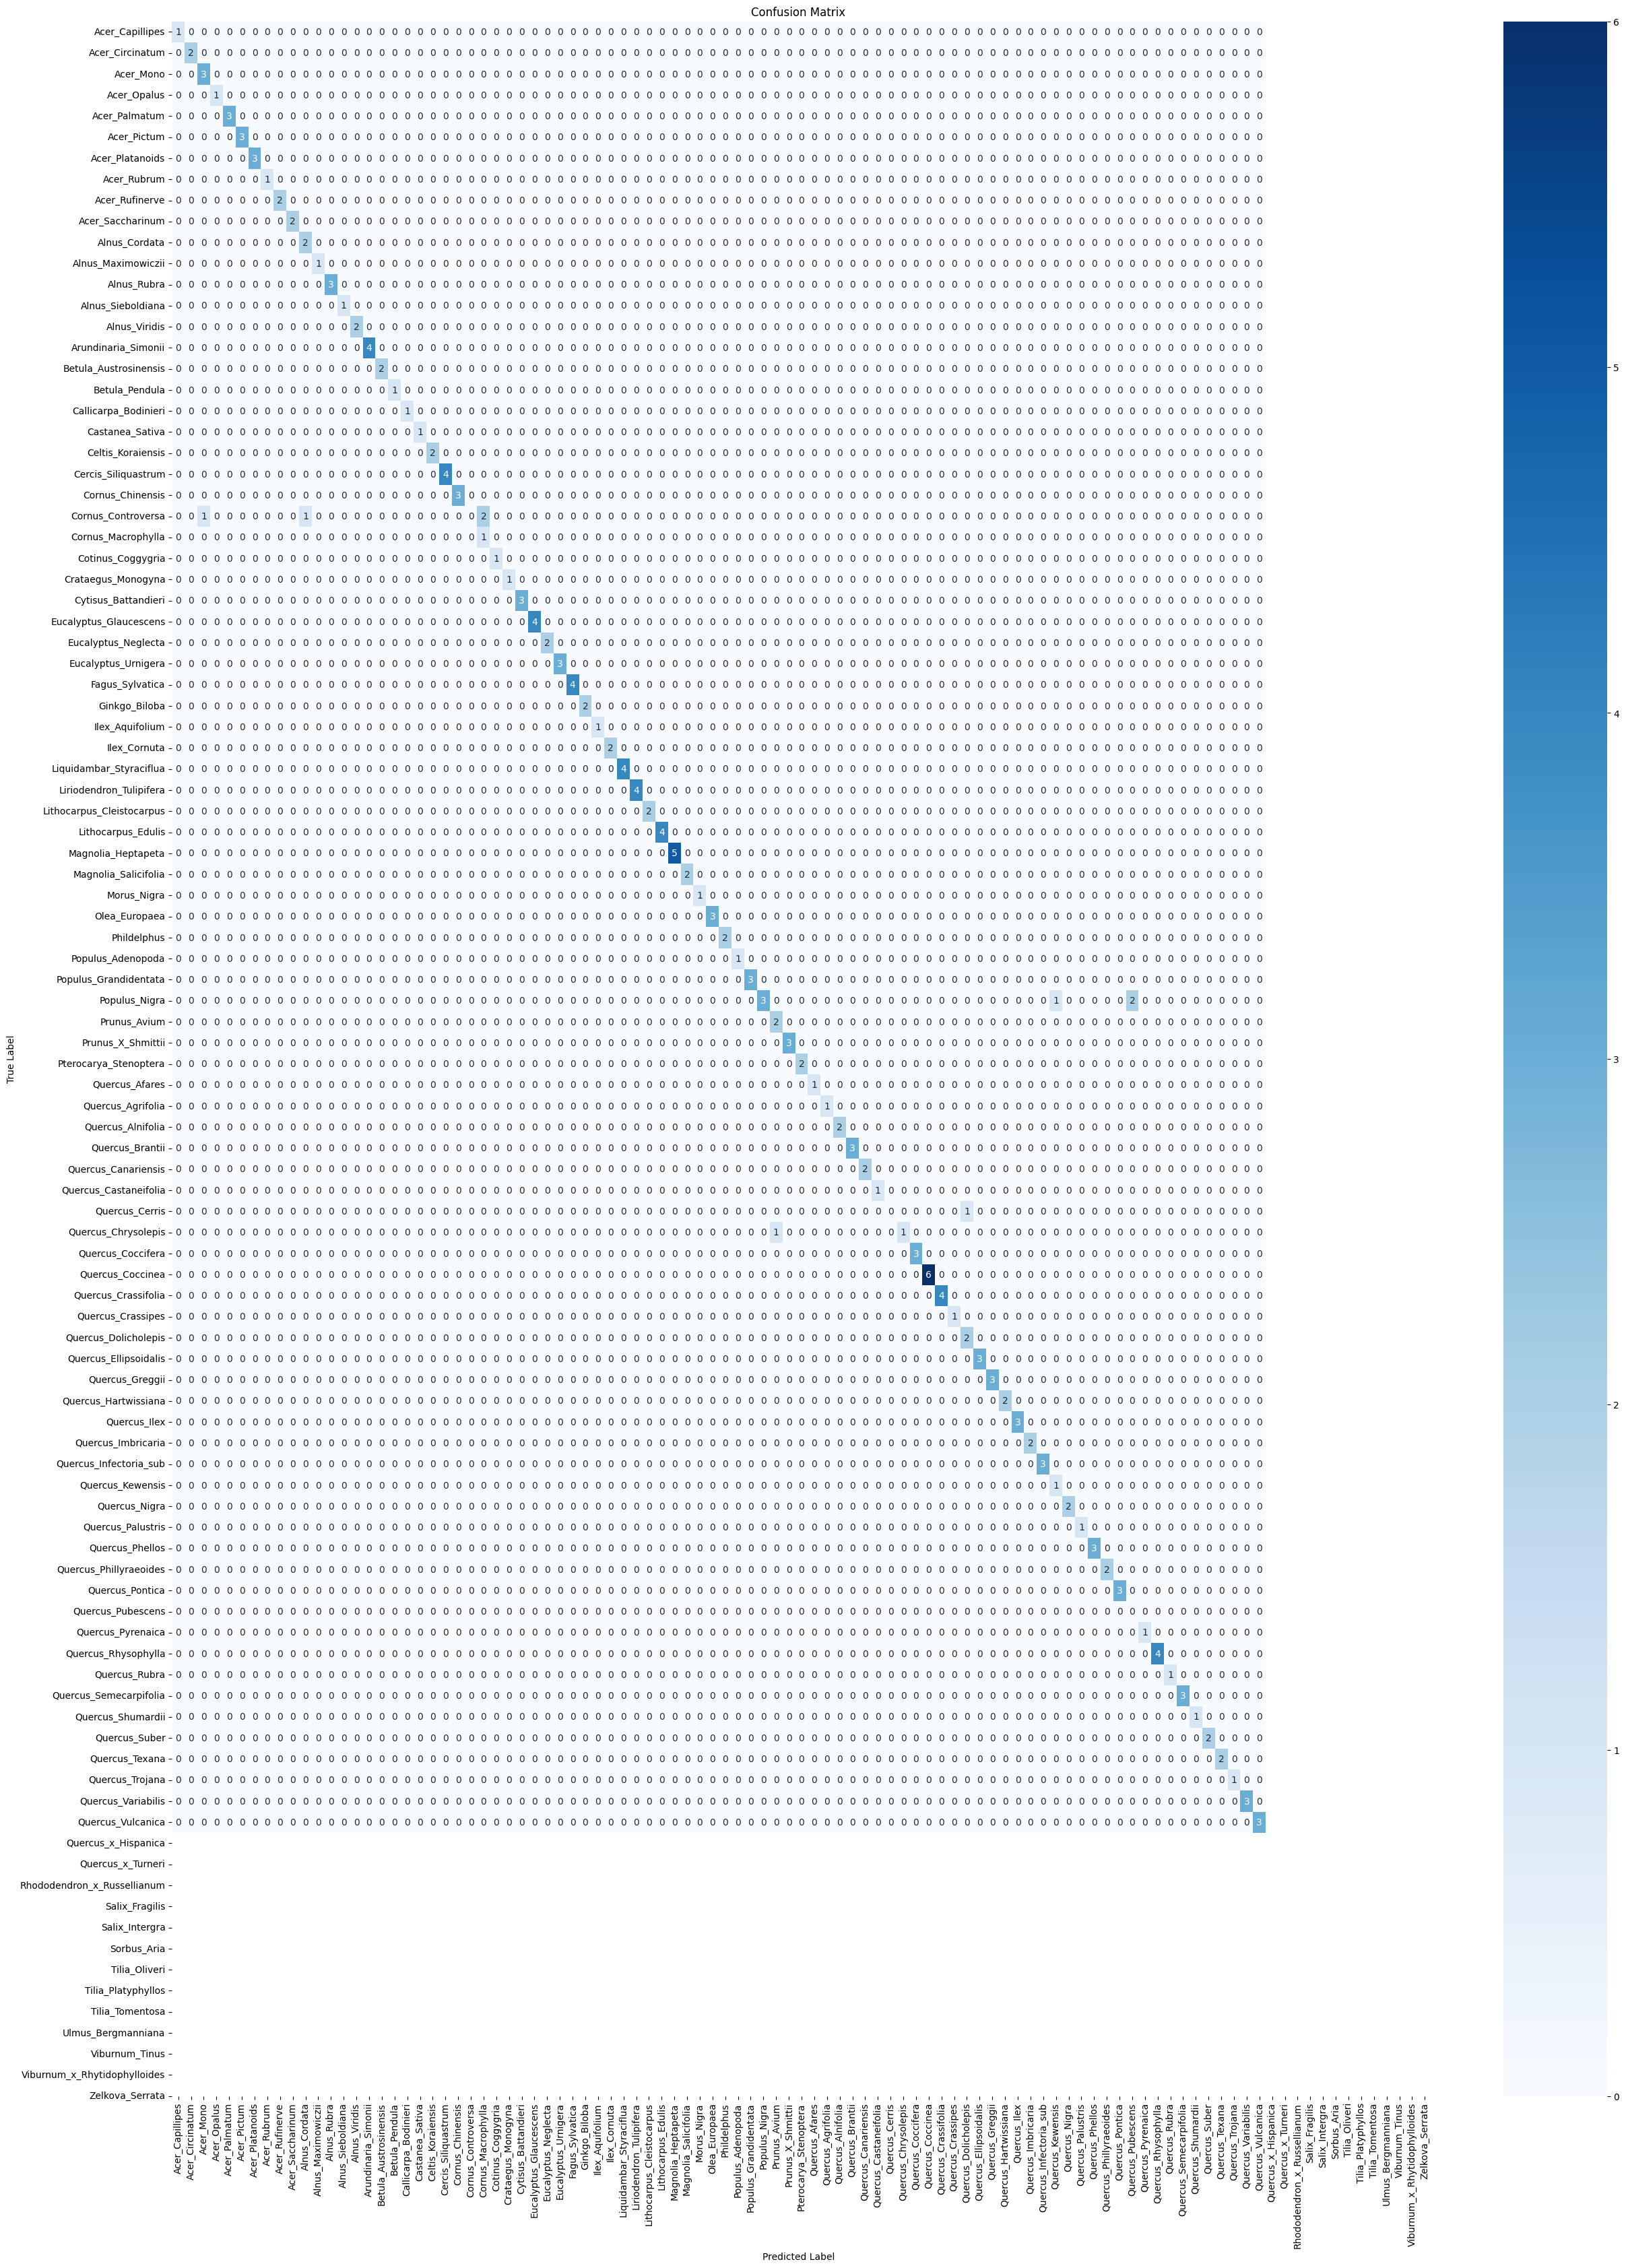

In [ ]:
# Predictions on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(30, 40))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Using the Same Test set

In [ ]:
# Read the data
data = pd.read_csv("train.csv")
# Use the "id" column as the index
data.set_index("id", drop = True, inplace = True)

# String of "id" numbers for the test set
test_idx = "22   45   56   58   61   67   73   75   76   78   81   87   88  101  108  115 118  124  133  143  145  146  148  152  165  179  189  202  211  212  214  235 239  245  246  247  249  253  263  265  270  278  294  302  306  315  322  325 330  340  342  345  349  354  357  367  369  376  383  386  388  392  394  409 410  411  415  420  423  427  431  433  435  443  444  446  454  459  460  466 470  475  478  481  491  493  501  510  516  519  521  532  535  538  545  552 553  569  570  571  572  581  589  601  641  647  669  671  672  680  682  689 698  700  710  711  712  716  724  733  737  741  745  756  757  758  762  763 766  767  768  771  779  784  789  796  797  801  802  803  805  807  809  811 813  828  837  838  849  855  858  862  863  866  871  874  879  881  892  900 904  911  915  916  923  931  932  939  942  951  952  955  959  961  963  971 976  983  994 1001 1004 1014 1017 1019 1024 1025 1031 1039 1041 1051 1056 1061 1066 1073 1087 1101 1112 1113 1117 1118 1120 1125 1128 1130 1142 1148 1159 1160 1165 1172 1180 1194 1202 1205 1208 1210 1213 1218 1220 1228 1229 1238 1242 1249 1253 1255 1263 1265 1276 1281 1286 1309 1310 1317 1320 1327 1329 1330 1342 1344 1346 1348 1350 1358 1360 1366 1367 1372 1377 1378 1379 1388 1390 1391 1393 1394 1395 1402 1405 1411 1417 1420 1424 1435 1442 1443 1467 1474 1475 1479 1483 1494 1496 1499 1500 1501 1506 1507 1509 1511 1518 1523 1536 1539 1541 1545 1548 1551 1552 1554 1557 1561 1562 1569 1575 1581 1584"
# Split the string by whitespace
test_idx = test_idx.split()
# Convert the list to type integer
test_idx = list(map(int, test_idx))
# Get the training index
train_idx = list(set(data.index) - set(test_idx))

# Use the training index to separate the training data
train = data.loc[train_idx, :]
# Reset the index
train.reset_index(drop = True, inplace = True)
# Use the test index to separate the test data
test = data.loc[test_idx, :]
# Reset the index
test.reset_index(drop = True, inplace = True)


In [ ]:
# Separate features and targets
X_train = train.drop(columns=['species'])
y_train = train[['species']]

X_test = test.drop(columns=['species'])
y_test = test[['species']]

# Verify the number of columns
num_cols_X_train = X_train.shape[1]
num_cols_y_train = y_train.shape[1]

print("Number of columns in X_train:", num_cols_X_train)
print("Number of columns in y_train:", num_cols_y_train)

# Get all unique species in y_train and count them
unique_species_train = y_train['species'].unique()
num_unique_species_train = len(unique_species_train)

print("Number of unique species in y_train:", num_unique_species_train)

Number of columns in X_train: 192
Number of columns in y_train: 1
Number of unique species in y_train: 99


In [ ]:
# Split data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test)

# Encode species labels into numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_split)
y_val_encoded = label_encoder.transform(y_val_split)
y_test_encoded = label_encoder.transform(y_test)

# Build and compile the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_unique_species_train, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train_encoded, epochs=250, batch_size=32, validation_data=(X_val_scaled, y_val_encoded))

# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)
print(f'Test loss: {loss:.3f}')
print(f'Test accuracy: {accuracy:.3f}')

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:134: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:134: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Epoch 1/250
18/18 [==============================] - 2s 24ms/step - loss: 4.7760 - accuracy: 0.0090 - val_loss: 4.7434 - val_accuracy: 0.0072
Epoch 2/250
18/18 [==============================] - 0s 11ms/step - loss: 4.7385 - accuracy: 0.0108 - val_loss: 4.7160 - val_accuracy: 0.0072
Epoch 3/250
18/18 [==============================] - 0s 12ms/step - loss: 4.7381 - accuracy: 0.0108 - val_loss: 4.6900 - val_accuracy: 0.0072
Epoch 4/250
18/18 [==============================] - 0s 13ms/step - loss: 4.6739 - accuracy: 0.0054 - val_loss: 4.6652 - val_accuracy: 0.0072
Epoch 5/250
18/18 [==============================] - 0s 12ms/step - loss: 4.6282 - accuracy: 0.0126 - val_loss: 4.6436 - val_accuracy: 0.0072
Epoch 6/250
18/18 [==============================] - 0s 12ms/step - loss: 4.5893 - accuracy: 0.0144 - val_loss: 4.6194 - val_accuracy: 0.0072
Epoch 7/250
18/18 [==============================] - 0s 12ms/step - loss: 4.5879 - accuracy: 0.0054 - val_loss: 4.6020 - val_accuracy: 0.0072
Epoch 

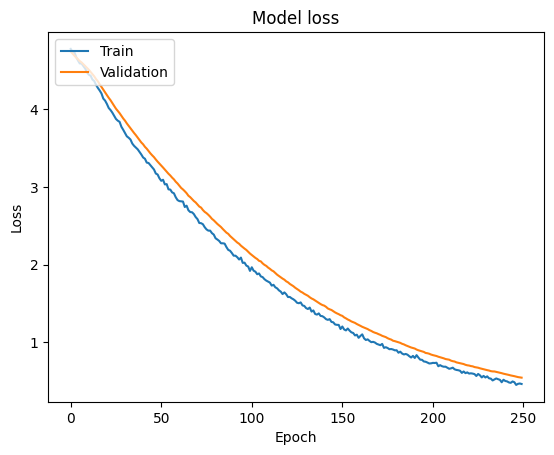

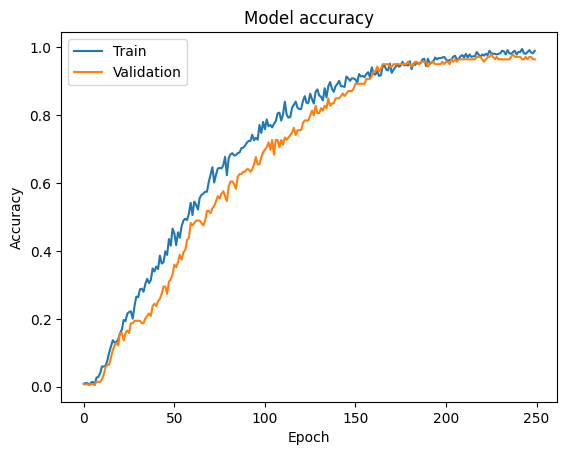

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

10/10 [==============================] - 0s 5ms/step


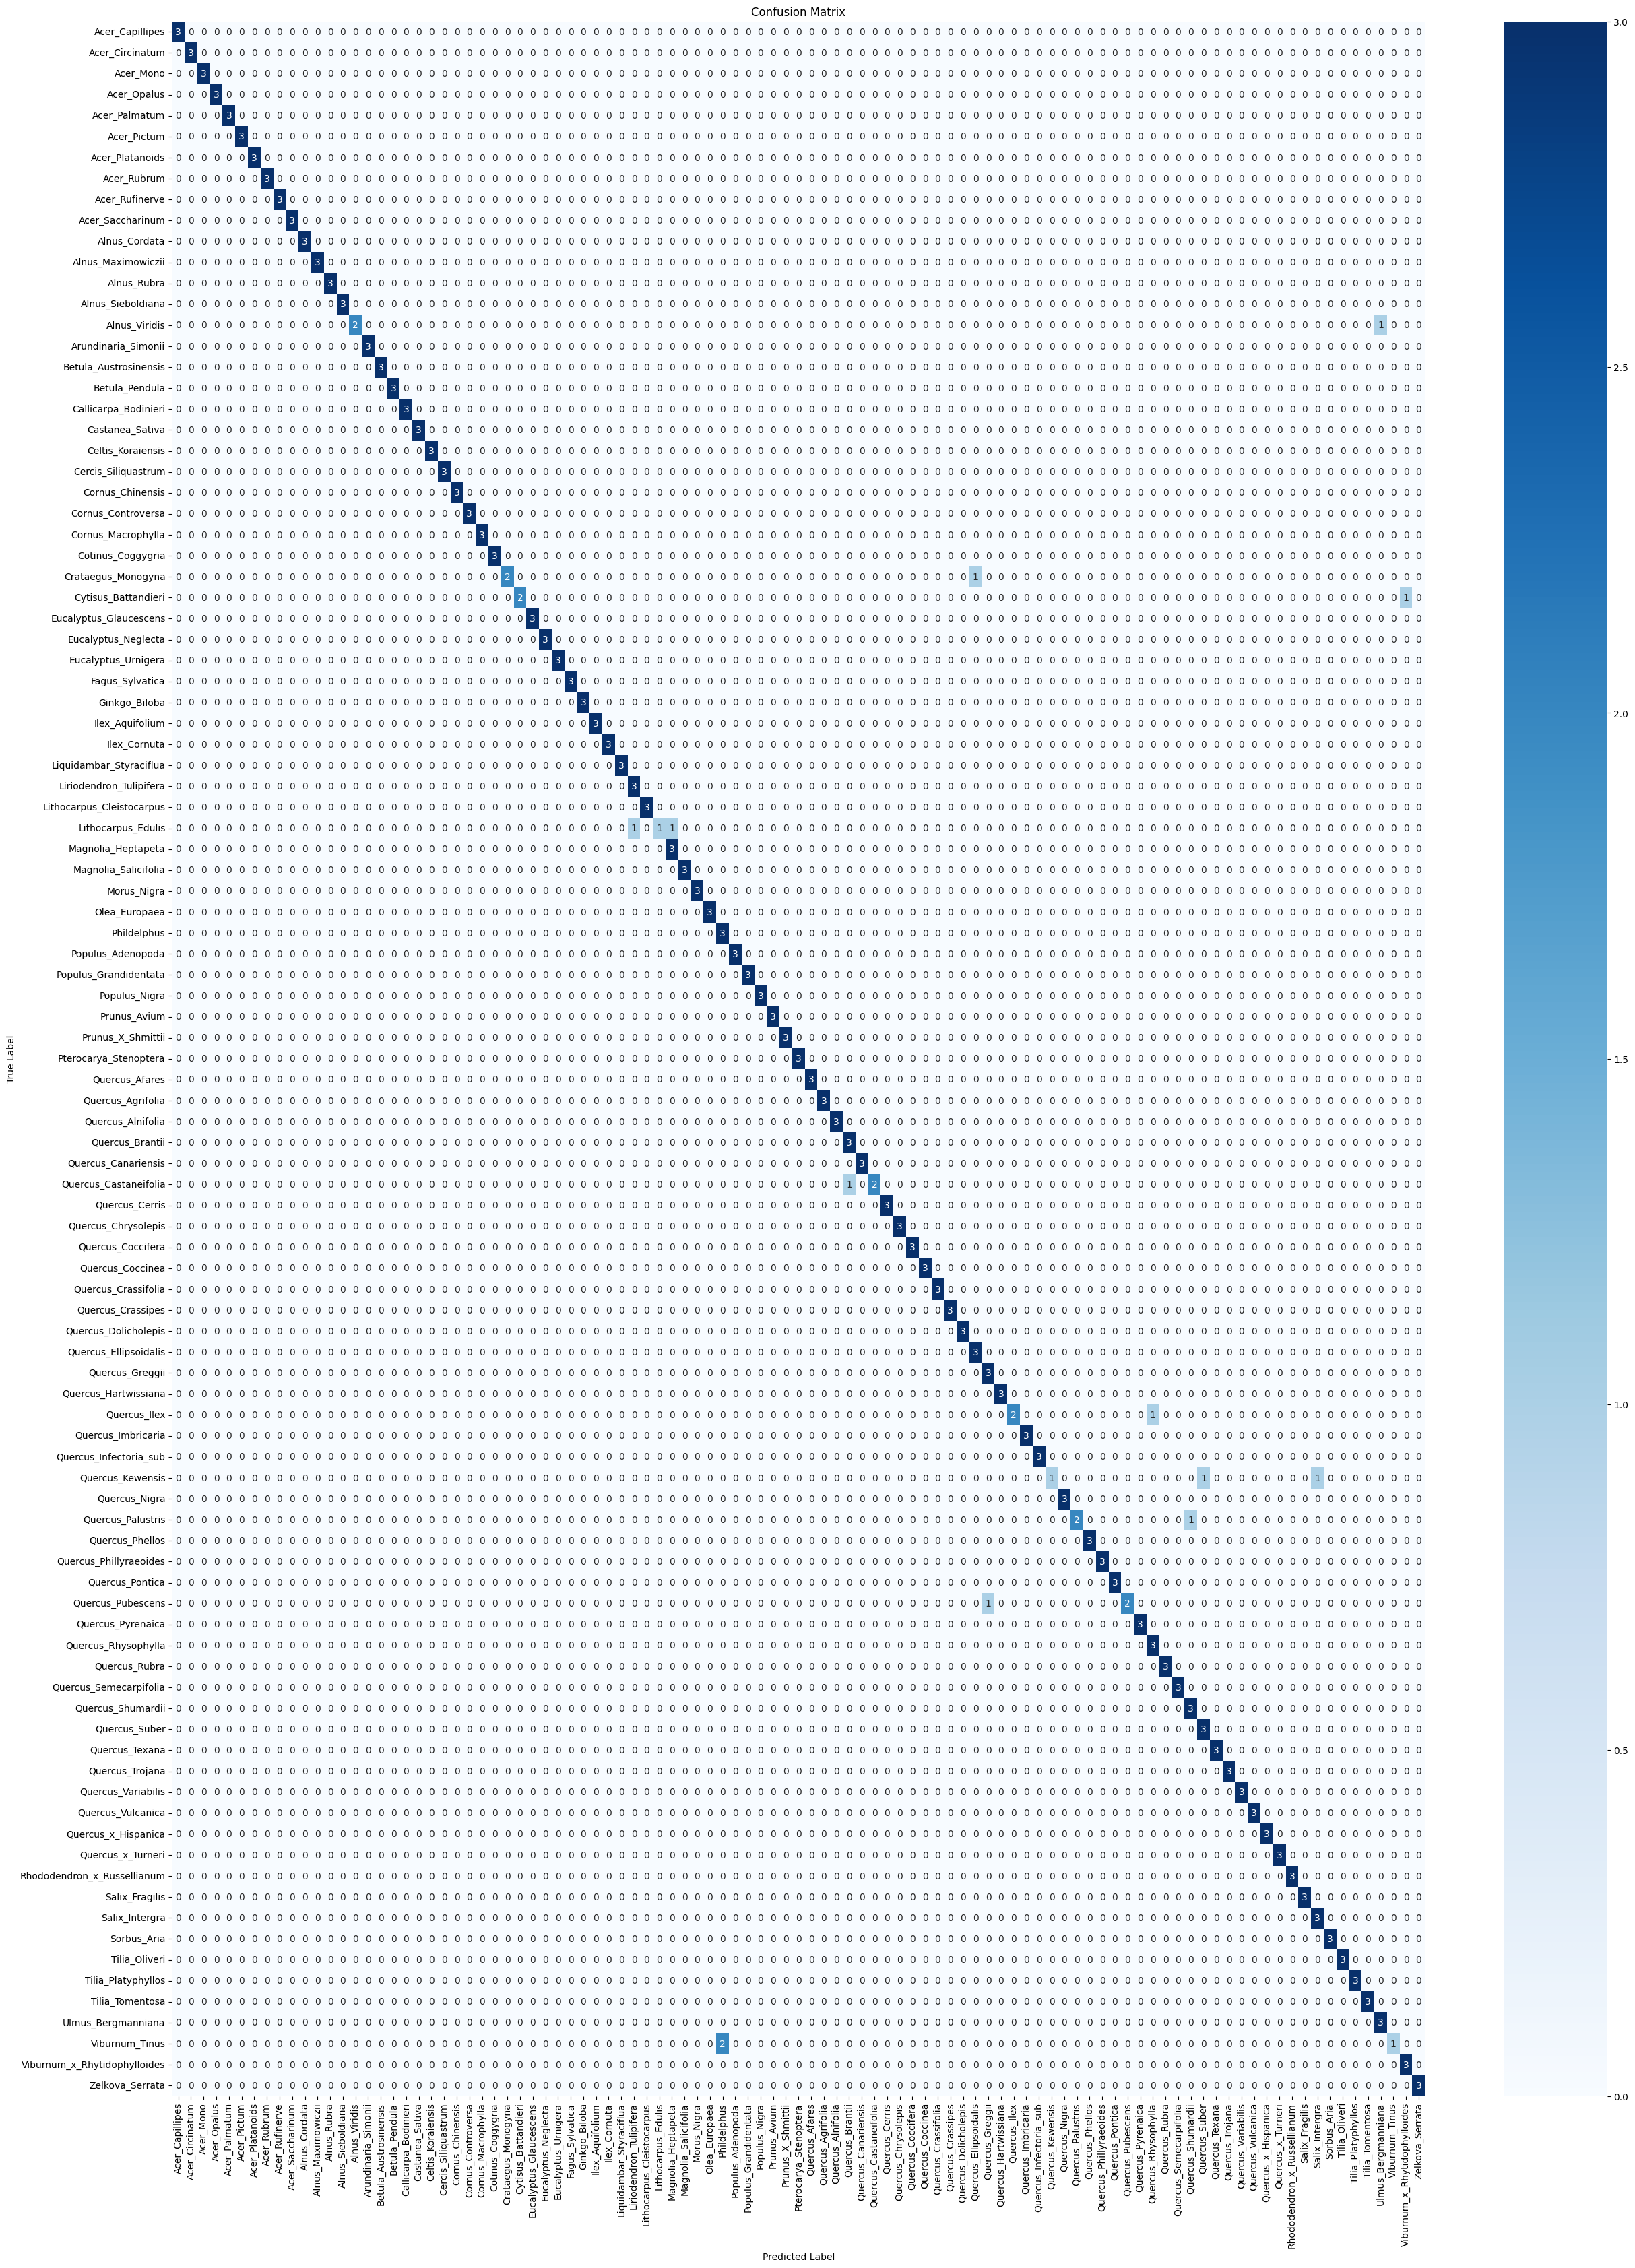

In [ ]:
# Predictions on the test set
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(30, 40))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Pretrain CNN Model

In [ ]:
image_gen = ImageDataGenerator(rescale = 1.0 / 255, validation_split = (2 / 7))

train_dir = "/content/train"
train_gen = image_gen.flow_from_directory(directory = train_dir,
                                          target_size = (96, 96),
                                          color_mode = "rgb",
                                          subset = "training",
                                          batch_size = 33)

valid_gen = image_gen.flow_from_directory(directory = train_dir,
                                          target_size = (96, 96),
                                          color_mode = "rgb",
                                          subset = "validation",
                                          batch_size = 33)

test_dir = "/content/test"
test_gen = image_gen.flow_from_directory(directory = test_dir,
                                         target_size = (96, 96),
                                         color_mode = "rgb",
                                         batch_size = 33)

Found 495 images belonging to 99 classes.
Found 198 images belonging to 99 classes.
Found 297 images belonging to 99 classes.


## VGG16

In [ ]:
# Load VGG16 model pre-trained on ImageNet data
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Freeze the convolutional base
base_model.trainable = False

# Add custom dense layers for classification
x = Flatten()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(99, activation='softmax')(x)


# Create the transfer learning model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model and save the history
history = model.fit(train_gen,
                    validation_data=valid_gen,
                    epochs=15,
                    batch_size=33)


Epoch 1/15
15/15 [==============================] - 52s 3s/step - loss: 4.7460 - accuracy: 0.0687 - val_loss: 3.3117 - val_accuracy: 0.3182
Epoch 2/15
15/15 [==============================] - 57s 4s/step - loss: 2.8523 - accuracy: 0.3414 - val_loss: 2.1906 - val_accuracy: 0.5354
Epoch 3/15
15/15 [==============================] - 56s 4s/step - loss: 1.8231 - accuracy: 0.5495 - val_loss: 1.5890 - val_accuracy: 0.6212
Epoch 4/15
15/15 [==============================] - 49s 3s/step - loss: 1.2780 - accuracy: 0.6586 - val_loss: 1.2460 - val_accuracy: 0.6869
Epoch 5/15
15/15 [==============================] - 56s 4s/step - loss: 0.9412 - accuracy: 0.7778 - val_loss: 0.9799 - val_accuracy: 0.7727
Epoch 6/15
15/15 [==============================] - 49s 3s/step - loss: 0.6973 - accuracy: 0.8283 - val_loss: 0.9406 - val_accuracy: 0.7424
Epoch 7/15
15/15 [==============================] - 56s 4s/step - loss: 0.5973 - accuracy: 0.8525 - val_loss: 0.8405 - val_accuracy: 0.7828
Epoch 8/15
15/15 [==

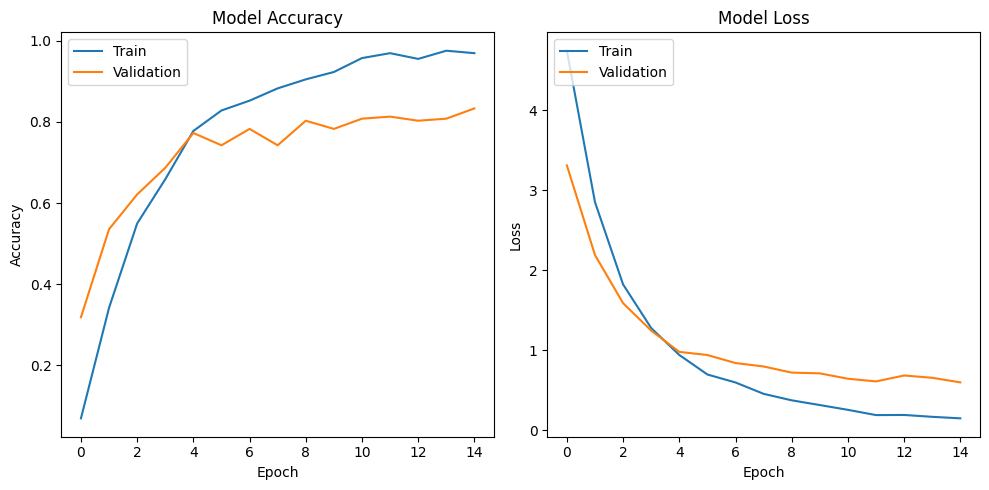

9/9 [==============================] - 21s 2s/step - loss: 0.7215 - accuracy: 0.8316
Test Loss: 0.7214967608451843
Test Accuracy: 0.8316498398780823


In [ ]:
# Plot training history
plt.figure(figsize=(10, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_gen)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

## InceptionV3



In [ ]:
# Load InceptionV3 model pre-trained on ImageNet data
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Freeze the convolutional base
base_model.trainable = False

# Add custom dense layers for classification
x = Flatten()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(99, activation='softmax')(x)

# Create the transfer learning model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(train_gen,
                    validation_data=valid_gen,
                    epochs=20,
                    callbacks=[reduce_lr, early_stop])

Epoch 1/20
15/15 [==============================] - 14s 592ms/step - loss: 5.0006 - accuracy: 0.0202 - val_loss: 4.1085 - val_accuracy: 0.1465 - lr: 1.0000e-04
Epoch 2/20
15/15 [==============================] - 8s 515ms/step - loss: 3.8167 - accuracy: 0.1434 - val_loss: 3.4981 - val_accuracy: 0.2778 - lr: 1.0000e-04
Epoch 3/20
15/15 [==============================] - 7s 507ms/step - loss: 3.1212 - accuracy: 0.2788 - val_loss: 3.0622 - val_accuracy: 0.3636 - lr: 1.0000e-04
Epoch 4/20
15/15 [==============================] - 7s 507ms/step - loss: 2.5850 - accuracy: 0.4222 - val_loss: 2.7118 - val_accuracy: 0.3939 - lr: 1.0000e-04
Epoch 5/20
15/15 [==============================] - 8s 512ms/step - loss: 2.1886 - accuracy: 0.5253 - val_loss: 2.4279 - val_accuracy: 0.5000 - lr: 1.0000e-04
Epoch 6/20
15/15 [==============================] - 8s 527ms/step - loss: 1.8638 - accuracy: 0.6222 - val_loss: 2.2084 - val_accuracy: 0.5303 - lr: 1.0000e-04
Epoch 7/20
15/15 [===========================

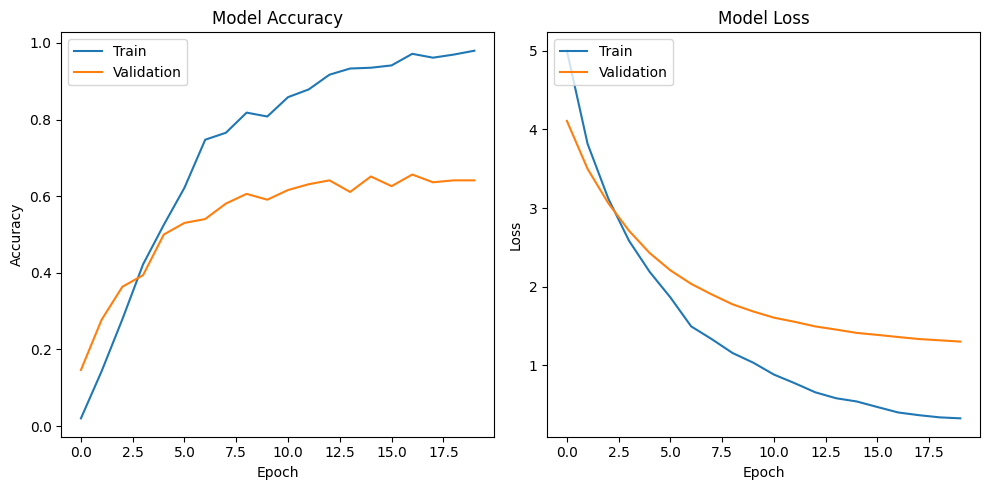

9/9 [==============================] - 3s 332ms/step - loss: 1.4887 - accuracy: 0.6061
Test Loss: 1.4886523485183716
Test Accuracy: 0.6060606241226196


In [ ]:
# Plot training history
plt.figure(figsize=(10, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_gen)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)